# Shor's Order-Finding and Factoring Algorithm

Find an unknown multiplicative order using quantum phase estimation, recover
it from rational approximations, and use it to factor an integer.

[The problem](#problem) · [Quantum section](#quantum) ·
[Classical section](#classical) · [Success and cost](#cost)

This notebook contains original explanations, executable Qiskit circuits,
classical recovery code, and saved results. Run the cells from top to bottom.
The examples use a local ideal simulator and require no IBM Quantum account.

<a id="problem"></a>
## 1. The problem

Given an integer $N\geq3$ and an integer $a$ with $1\leq a<N$ and
$\gcd(a,N)=1$, **order finding** asks for the smallest positive integer $r$ such that

$$
a^r\equiv1\pmod N.
$$

The order is unknown. It satisfies $1\leq r\leq\varphi(N)<N$.

For the **factoring application**, assume $N=pq$, where $p$ and $q$ are
primes. The objective is to recover these two factors from $N$ alone.
Even $N$ and perfect squares can be handled classically. The quantum
procedure is used for the remaining case of distinct odd primes.

For example, $a=2$ modulo $N=21$ has order $6$. A successful order-finding
routine receives only $a$ and $N$. The value $6$ is a reference answer for
checking this example, not an input to its circuit or recovery algorithm.

Once a suitable even order is known, the classical step computes

$$
\gcd(a^{r/2}-1,N)
\quad\text{and}\quad
\gcd(a^{r/2}+1,N).
$$

We derive the conditions under which these are nontrivial factors below.

### Why this belongs beyond finite abelian hidden subgroups

Extend modular exponentiation to every integer $x$ using the inverse of
$a$ for negative exponents. The function

$$
f:\mathbb Z\longrightarrow(\mathbb Z/N\mathbb Z)^\times,
\qquad f(x)=a^x\bmod N
$$

satisfies

$$
f(x)=f(y)
\quad\Longleftrightarrow\quad
x-y\in r\mathbb Z.
$$

Thus the exact hidden subgroup is $K=r\mathbb Z$ inside the infinite
abelian group $G=\mathbb Z$. The finite output modulus $N$ does not make
the exponent domain finite.

A quantum computer uses a finite register of size $Q=2^t$. The restriction
of $f$ to $0,\ldots,Q-1$ is an exact hiding function on $\mathbb Z_Q$
only when $r\mid Q$. We cannot assume this for an unknown order.
Phase estimation instead gives approximate rational information about $s/r$.

This develops the order-finding ingredient of
[Shor's algorithm](https://arxiv.org/abs/quant-ph/9508027).
For the distinction between finite cyclic period finding and period finding
over $\mathbb Z$, see
[Childs and van Dam, Section IV](https://arxiv.org/html/0812.0380v1#S4.SS4).

<a id="quantum"></a>
## 2. Quantum section

### Modular multiplication and its eigenstates

Let $n=\lceil\log_2N\rceil$. On the $n$-qubit work register, define

$$
U_a\lvert z\rangle=
\begin{cases}
\lvert az\bmod N\rangle,&0\leq z<N,\\
\lvert z\rangle,&N\leq z<2^n.
\end{cases}
$$

Multiplication by $a$ permutes the valid residues because $\gcd(a,N)=1$.
Fixing the unused encodings therefore extends this operation to a unitary.

The orbit of $1$ consists of the $r$ distinct residues
$1,a,\ldots,a^{r-1}\bmod N$. For $s=0,\ldots,r-1$, define

$$
\lvert u_s\rangle=
\frac1{\sqrt r}\sum_{k=0}^{r-1}
e^{-2\pi i sk/r}\lvert a^k\bmod N\rangle.
$$

Changing the summation index after multiplication gives

$$
U_a\lvert u_s\rangle=e^{2\pi i s/r}\lvert u_s\rangle.
$$

The algorithm does not need to know $r$ to prepare these eigenstates.
Instead, initialize the work register to $1$. Orthogonality of the roots
of unity gives

$$
\lvert1\rangle=\frac1{\sqrt r}\sum_{s=0}^{r-1}\lvert u_s\rangle.
$$

Phase estimation on this state is equivalent, for the measured phase
distribution, to choosing a uniformly random $s$ and estimating $s/r$.

### Phase estimation and the measurement distribution

Choose $t=2n$ and $Q=2^t$, so $Q\geq N^2$. Prepare the phase register in
$Q^{-1/2}\sum_{x=0}^{Q-1}\lvert x\rangle$ with Hadamard gates. Bit $j$
controls $U_a^{2^j}$. For a work-register eigenstate, this produces

$$
\frac1{\sqrt Q}\sum_{x=0}^{Q-1}
e^{2\pi i xs/r}\lvert x\rangle\lvert u_s\rangle.
$$

Apply the inverse Fourier transform with convention

$$
F_Q^\dagger\lvert x\rangle
=\frac1{\sqrt Q}\sum_{y=0}^{Q-1}
e^{-2\pi i xy/Q}\lvert y\rangle.
$$

The full output state is

$$
\frac1{\sqrt r}\sum_{s=0}^{r-1}\sum_{y=0}^{Q-1}
A_s(y)\lvert y\rangle\lvert u_s\rangle,
\qquad
A_s(y)=\frac1Q\sum_{x=0}^{Q-1}
e^{2\pi i x(s/r-y/Q)}.
$$

Consequently,

$$
\Pr(Y=y)=\frac1r\sum_{s=0}^{r-1}|A_s(y)|^2.
$$

If $r\mid Q$, all phases are exactly representable. Otherwise there are
peaks near $y=Qs/r$ and smaller probabilities away from them. A nearest
integer $y$ to $Qs/r$ occurs with conditional probability at least
$4/\pi^2$ and satisfies

$$
\left|\frac yQ-\frac sr\right|
\leq\frac1{2Q}<\frac1{2r^2}.
$$

This accuracy is sufficient for continued fractions. It is a probabilistic
event, not a property of every shot. Since $Q\geq N^2$ and $r<N$, the
nearest integers to these phases lie in $0,\ldots,Q-1$ without wrapping.

### Qiskit implementation

The code builds each controlled power from the public constant
$c=a^{2^j}\bmod N$, computed by repeated squaring. It never computes
$r$ to construct the circuit.

For transparency, the small examples represent modular multipliers as
dense permutation matrices. Their storage grows exponentially in $n$.
A scalable implementation must replace them with reversible arithmetic
circuits. Controlled gates use deferred annotations so the local simulator
can apply their matrices without first synthesizing long gate decompositions. The inverse QFT uses a gate decomposition, avoiding a dense
$Q\times Q$ Fourier matrix.

Dependencies are shared with the other notebooks in this repository.

In [1]:
# Run this only if the dependencies are missing.
# %pip install -r requirements.txt

In [2]:
from collections import Counter
from fractions import Fraction
from math import gcd, isqrt, lcm, pi

import numpy as np
import matplotlib.pyplot as plt
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.primitives import StatevectorSampler
from IPython.display import display

print("Qiskit:", qiskit.__version__)
print("NumPy:", np.__version__)

Qiskit: 2.5.2
NumPy: 2.5.3


In [3]:
def check_order_inputs(a, N):
    if type(N) is not int or N < 3:
        raise ValueError("N must be an integer at least 3.")
    if type(a) is not int or not 1 <= a < N or gcd(a, N) != 1:
        raise ValueError("Require 1 <= a < N and gcd(a, N) = 1.")
    return (N - 1).bit_length()


def modular_multiplier(c, N):
    '''Dense demonstration gate, with unused encodings fixed.'''
    if type(N) is not int or N < 3 or type(c) is not int:
        raise ValueError("Require integer N >= 3 and integer c.")
    c %= N
    if gcd(c, N) != 1:
        raise ValueError("The multiplier must be invertible modulo N.")
    n = (N - 1).bit_length()
    if n > 6:
        raise ValueError("This dense demonstration supports at most 6 work qubits.")
    dimension = 1 << n
    matrix = np.zeros((dimension, dimension), dtype=complex)
    for z in range(dimension):
        target = c * z % N if z < N else z
        matrix[target, z] = 1
    gate = UnitaryGate(matrix, label=rf"$M_{{{c}}}$")
    gate.name = f"M_{c}"  # Deferred controls display the base operation's name.
    return gate


def order_finding_circuit(a, N):
    '''QPE with t = 2n phase qubits, without knowing the order.'''
    n = check_order_inputs(a, N)
    if n > 6:
        raise ValueError("The local dense simulation is limited to 18 total qubits.")
    t = 2 * n
    phase = QuantumRegister(t, "phase")
    work = QuantumRegister(n, "work")
    measured = ClassicalRegister(t, "phase_bits")
    circuit = QuantumCircuit(phase, work, measured)

    circuit.x(work[0])  # Little-endian encoding of the multiplicative identity.
    circuit.h(phase)
    c = a
    for j in range(t):
        if c != 1:
            circuit.append(modular_multiplier(c, N).control(1, annotated=True),
                           [phase[j], *work])
        c = c * c % N

    # Wrap the decomposed inverse QFT so simulation uses H, phase and swap gates.
    iqft = QFTGate(t).inverse().definition.to_gate(label=r"$F_Q^\dagger$")
    circuit.append(iqft, phase)
    circuit.measure(phase, measured)
    return circuit


def sample_order_phases(a, N, shots=128, seed=2026):
    if type(shots) is not int or shots < 1:
        raise ValueError("shots must be a positive integer.")
    circuit = order_finding_circuit(a, N)
    rng = seed if isinstance(seed, np.random.Generator) else np.random.default_rng(seed)
    result = StatevectorSampler(seed=rng).run([circuit], shots=shots).result()[0]
    bitstrings = result.data.phase_bits.get_bitstrings()
    # Qiskit displays highest-index classical bits on the left.
    # Measuring phase[j] into bit j therefore needs no bit reversal.
    return [int(bits, 2) for bits in bitstrings], circuit

### A nonexact phase example

We use $N=21$ and $a=2$. Here $n=5$, $t=10$, and $Q=1024$.
The reference order $r=6$ does not divide $Q$, so this example exposes
the approximation in phase estimation.

The following figure shows the implemented circuit. The multiplier
labels are the known constants $a^{2^j}\bmod N$. The work register is
left unmeasured.

N = 21, a = 2, phase qubits = 10, work qubits = 5
Most frequent phase outcomes: [(512, 185), (0, 150), (683, 135), (853, 128), (341, 122), (171, 117), (854, 26), (682, 25)]


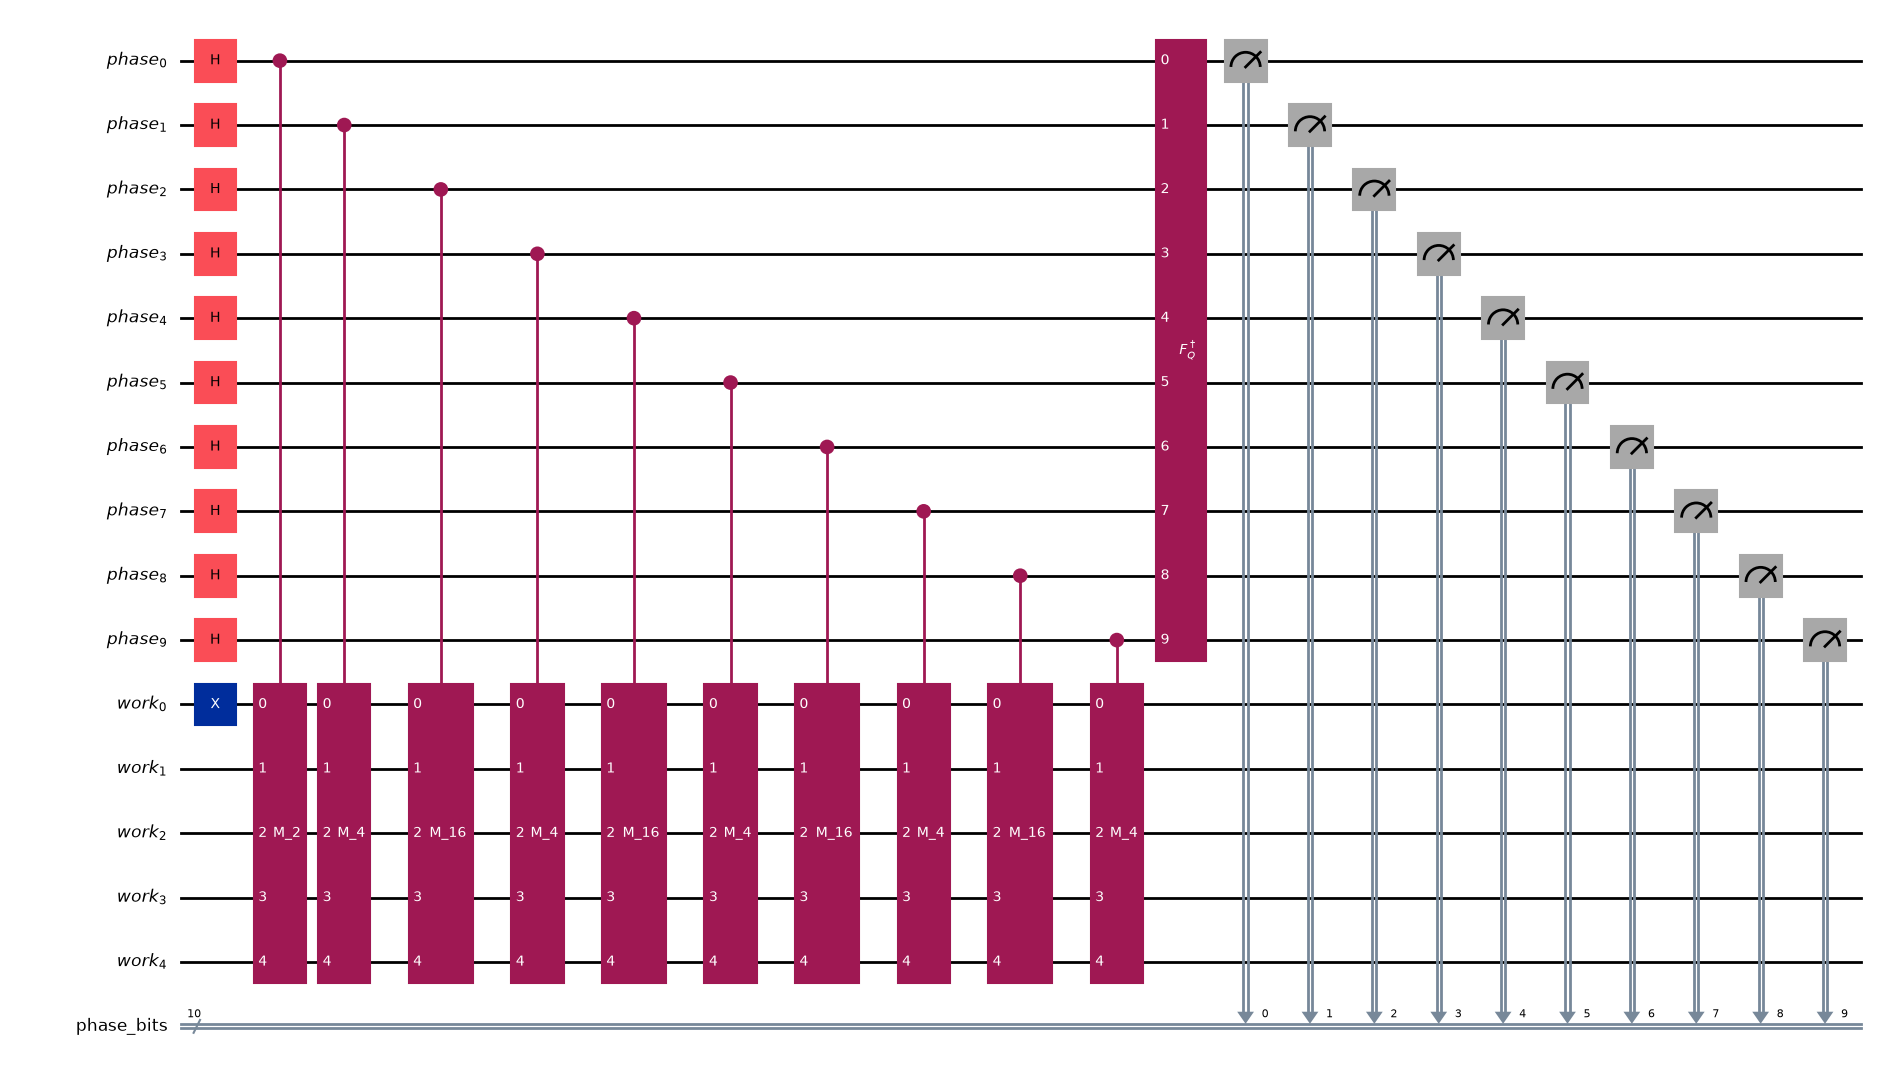

In [4]:
N, a = 21, 2
phase_samples, circuit = sample_order_phases(a, N, shots=1024, seed=2026)
t = 2 * (N - 1).bit_length()
Q = 1 << t
print(f"N = {N}, a = {a}, phase qubits = {t}, work qubits = {t // 2}")
print("Most frequent phase outcomes:", Counter(phase_samples).most_common(8))
display(circuit.draw("mpl", fold=-1, style={"fontsize": 10}, scale=1.0))
plt.close("all")

The histogram shows measured values of $y/Q$. Dashed lines mark the
reference phases $s/6$ for comparison. The reference order is used only
to annotate this figure, not to generate the circuit or its samples.

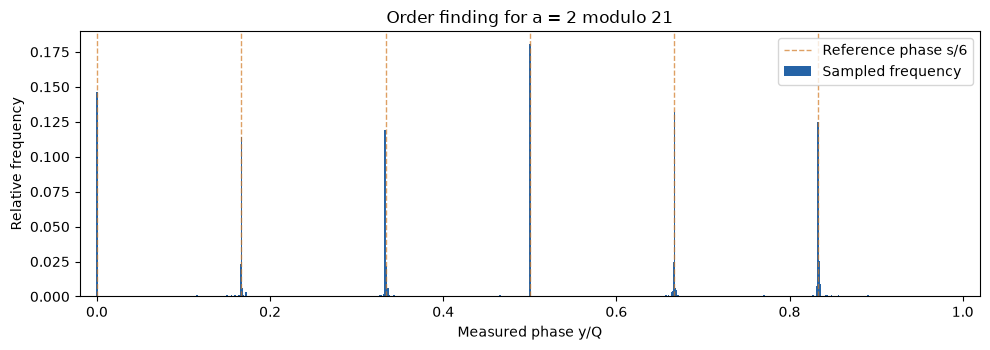

In [5]:
counts = Counter(phase_samples)
values = np.array(sorted(counts))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(values / Q, [counts[y] / len(phase_samples) for y in values],
       width=2 / Q, color="#2563a6", label="Sampled frequency")
for s in range(6):
    ax.axvline(s / 6, color="#d07822", linestyle="--", linewidth=1,
               alpha=0.7, label="Reference phase s/6" if s == 0 else None)
ax.set(xlabel="Measured phase y/Q", ylabel="Relative frequency",
       title="Order finding for a = 2 modulo 21", xlim=(-0.02, 1.02))
ax.legend()
fig.tight_layout()
plt.show()

<a id="classical"></a>
## 3. Classical section

### Continued fractions recover a reduced phase

An accurate measurement approximates the reduced fraction

$$
\frac sr=\frac bd,
\qquad
d=\frac r{\gcd(s,r)}.
$$

Thus one denominator may be only a divisor of $r$. If $s=0$, the
denominator is $1$ and reveals no nontrivial order information.

A reduced fraction $b/d$ with
$|y/Q-b/d|<1/(2d^2)$ is a continued-fraction convergent of $y/Q$.
We enumerate convergents and retain one with $d<N$ and

$$
\left|\frac yQ-\frac bd\right|\leq\frac1{2Q}
\quad\Longleftrightarrow\quad
2|yd-Qb|\leq d.
$$

The integer test avoids rounding errors. There is at most one such
fraction. Two different reduced fractions with denominators below $N$
differ by more than $1/N^2$, whereas two passing this test would differ
by at most $1/Q\leq1/N^2$.

On a nearest-phase outcome this recovers $s/r$ in reduced form.
On an inaccurate outcome, it may reject the sample or accept an
unrelated fraction. Passing this filter alone does not certify a
divisor of the true order.

In [6]:
def convergents(numerator, denominator):
    '''Convergents of a nonnegative rational, using integer arithmetic.'''
    if (type(numerator) is not int or type(denominator) is not int
            or numerator < 0 or denominator <= 0):
        raise ValueError("Require a nonnegative numerator and positive denominator.")
    prev_num, curr_num = 0, 1
    prev_den, curr_den = 1, 0
    while denominator:
        quotient, remainder = divmod(numerator, denominator)
        next_num = quotient * curr_num + prev_num
        next_den = quotient * curr_den + prev_den
        yield next_num, next_den
        prev_num, curr_num = curr_num, next_num
        prev_den, curr_den = curr_den, next_den
        numerator, denominator = denominator, remainder


def phase_fraction(y, Q, N):
    '''Return the unique sufficiently close convergent, or None.'''
    if (type(N) is not int or N < 3 or type(Q) is not int or Q < N * N
            or type(y) is not int or not 0 <= y < Q):
        raise ValueError("Require N >= 3, Q >= N**2, and 0 <= y < Q.")
    for b, d in convergents(y, Q):
        if d >= N:
            break
        if 2 * abs(y * d - Q * b) <= d:
            return Fraction(b, d)
    return None

### Combine two shots, then repeat independently

For two accurate shots with phase indices $s_1,s_2$, the recovered
denominators satisfy

$$
\operatorname{lcm}(d_1,d_2)
=\frac r{\gcd(r,s_1,s_2)}.
$$

When the gcd on the right is $1$, their least common multiple is $r$,
even if neither denominator equals $r$ by itself.

For each disjoint pair of shots, form $M=\operatorname{lcm}(d_1,d_2)$.
Discard a pair if either fraction is missing, $M\geq N$, or
$a^M\not\equiv1\pmod N$. Every retained $M$ is a positive multiple of $r$.

**The modular-power check certifies a period, not its minimality.**
Keep the smallest retained $M$ across a fixed number of independent
pairs. If even one pair recovers $r$, this minimum is exactly $r$.
Otherwise it can remain a larger multiple, or there may be no candidate.
The success analysis below bounds this uncertainty without factoring $M$
or searching classically through possible orders.

In [7]:
PAIR_SUCCESS_LOWER_BOUND = 96 / pi**6


def recover_order_candidate(samples, Q, a, N):
    '''Minimum verified period from disjoint pairs. Exact order is probabilistic.'''
    check_order_inputs(a, N)
    if type(Q) is not int or Q < N * N:
        raise ValueError("Require Q >= N**2.")
    samples = list(samples)
    if not samples or len(samples) % 2:
        raise ValueError("Supply a positive even number of phase samples.")
    fractions = [phase_fraction(y, Q, N) for y in samples]
    verified = []
    for index in range(0, len(fractions), 2):
        first, second = fractions[index:index + 2]
        if first is None or second is None:
            continue
        M = lcm(first.denominator, second.denominator)
        if M < N and pow(a, M, N) == 1:
            verified.append(M)
    pairs = len(samples) // 2
    return {
        "candidate": min(verified) if verified else None,
        "verified_period": bool(verified),
        "pairs": pairs,
        "verified_pairs": len(verified),
        "ideal_failure_bound": (1 - PAIR_SUCCESS_LOWER_BOUND)**pairs,
    }


def find_order(a, N, pairs=64, seed=2026):
    '''Return a verified period that equals the order with the stated probability.'''
    check_order_inputs(a, N)
    if type(pairs) is not int or pairs < 1:
        raise ValueError("pairs must be a positive integer.")
    if a == 1:
        return {"candidate": 1, "verified_period": True, "pairs": 0,
                "verified_pairs": 0, "ideal_failure_bound": 0.0}
    samples, _ = sample_order_phases(a, N, shots=2 * pairs, seed=seed)
    Q = 1 << (2 * (N - 1).bit_length())
    return recover_order_candidate(samples, Q, a, N)

### Recover the example order

For $r=6$, phases $1/3$ and $1/2$ have denominators $3$ and $2$.
Their least common multiple recovers $6$. First check that arithmetic
with constructed nearest outcomes, then apply the same recovery to
the actual Qiskit samples.

The reported failure bound concerns independent ideal QPE shots.
It is not a confidence estimate for arbitrary supplied data or noisy hardware.

In [8]:
constructed = [round(Q / 3), Q // 2]
print("Constructed phase fractions:",
      [str(phase_fraction(y, Q, N)) for y in constructed])
constructed_result = recover_order_candidate(constructed, Q, a, N)
print("Constructed pair:", constructed_result["candidate"])
assert constructed_result["candidate"] == 6

recovery = recover_order_candidate(phase_samples[:128], Q, a, N)
print("Recovery from 128 Qiskit shots:", recovery)
assert recovery["candidate"] == 6
assert pow(a, recovery["candidate"], N) == 1

Constructed phase fractions: ['1/3', '1/2']
Constructed pair: 6
Recovery from 128 Qiskit shots: {'candidate': 6, 'verified_period': True, 'pairs': 64, 'verified_pairs': 29, 'ideal_failure_bound': 0.0011911948815567363}


### From a verified period to factors

Let $M$ be any positive integer satisfying $a^M\equiv1\pmod N$.
If $M$ is even, set $x=a^{M/2}\bmod N$. Then

$$
(x-1)(x+1)\equiv0\pmod N.
$$

For distinct odd primes $p,q$, if $x\not\equiv1,-1\pmod N$, the residues
of $x$ modulo the two primes have opposite signs. Therefore

$$
\{\gcd(x-1,N),\gcd(x+1,N)\}=\{p,q\}.
$$

A verified multiple of the order is sufficient when this test succeeds.
If $M$ is odd or $x$ is $1$ or $-1$ modulo $N$, try another base.
Before invoking the quantum circuit, $\gcd(a,N)>1$ already supplies a factor.

The implementation verifies each returned divisor and its product with
the other factor. It uses bounded attempts and reports failure if no
factor is found. Under the promise $N=pq$, the returned nontrivial factor
pair is the prime factorization. The routine does not prove the input
promise or attempt general recursive factorization.

In [9]:
def checked_factor_pair(N, divisor):
    if 1 < divisor < N and N % divisor == 0:
        pair = tuple(sorted((divisor, N // divisor)))
        if pair[0] * pair[1] == N:
            return pair
    return None


def factors_from_period(a, N, M):
    '''Return verified factors, or None for an unhelpful period.'''
    check_order_inputs(a, N)
    if type(M) is not int or M < 1 or M % 2 or pow(a, M, N) != 1:
        return None
    x = pow(a, M // 2, N)
    if x in (1, N - 1):
        return None
    for divisor in (gcd(x - 1, N), gcd(x + 1, N)):
        pair = checked_factor_pair(N, divisor)
        if pair is not None:
            return pair
    return None


def factor_semiprime(N, max_attempts=8, pairs=64, seed=2026):
    '''Factor promised N = p*q. Exhaustion raises RuntimeError.'''
    if type(N) is not int or N < 4:
        raise ValueError("N must be an integer at least 4, promised to equal p*q.")
    if (type(max_attempts) is not int or max_attempts < 1
            or type(pairs) is not int or pairs < 1):
        raise ValueError("Attempt and pair budgets must be positive integers.")
    if N % 2 == 0:
        return {"factors": checked_factor_pair(N, 2), "method": "even input",
                "attempts": []}
    root = isqrt(N)
    if root * root == N:
        return {"factors": checked_factor_pair(N, root), "method": "perfect square",
                "attempts": []}
    if (N - 1).bit_length() > 6:
        raise ValueError("This dense quantum demonstration supports N <= 64.")

    rng = np.random.default_rng(seed)
    attempts = []
    for _ in range(max_attempts):
        a = int(rng.integers(2, N - 1))
        divisor = gcd(a, N)
        if divisor > 1:
            attempts.append({"base": a, "gcd": divisor})
            return {"factors": checked_factor_pair(N, divisor),
                    "method": "classical gcd", "attempts": attempts}
        result = find_order(a, N, pairs=pairs, seed=rng)
        M = result["candidate"]
        attempts.append({"base": a, "period_candidate": M})
        pair = factors_from_period(a, N, M) if M is not None else None
        if pair is not None:
            return {"factors": pair, "method": "quantum order finding",
                    "attempts": attempts}
    raise RuntimeError("Attempt budget exhausted. Increase the budget or change the seed.")

### Factoring demonstration and boundary cases

The first computation below factors $21$ using the period obtained
from the quantum samples above. The complete wrapper then chooses its
own bases. It may succeed through either a gcd shortcut or quantum
order finding, and reports which route it used.

The final checks show why unsuccessful periods should lead to retries.
An even verified period can still be unhelpful.

In [10]:
factors = factors_from_period(a, N, recovery["candidate"])
print("Factors from the sampled period:", factors)
assert factors == (3, 7)

full_result = factor_semiprime(15, seed=7)
print("Complete factoring procedure:", full_result)
assert full_result["factors"] == (3, 5)

print("Even semiprime:", factor_semiprime(14)["factors"])
print("Prime square:", factor_semiprime(49)["factors"])
print("Identity has order:", find_order(1, 21)["candidate"])

assert factors_from_period(2, 21, 12) is None  # A multiple can give x = 1.
assert factors_from_period(20, 21, 2) is None  # Here x = -1.
assert factors_from_period(4, 21, 3) is None   # Odd order.
assert factors_from_period(2, 21, 5) is None   # Not a period.
empty_result = recover_order_candidate([0, 0], Q, 2, 21)
assert empty_result["candidate"] is None
print("Uninformative samples and unhelpful periods are rejected.")

Factors from the sampled period: (3, 7)
Complete factoring procedure: {'factors': (3, 5), 'method': 'quantum order finding', 'attempts': [{'base': 13, 'period_candidate': 4}]}
Even semiprime: (2, 7)
Prime square: (7, 7)
Identity has order: 1
Uninformative samples and unhelpful periods are rejected.


<a id="cost"></a>
## 4. Success probability and computational cost

### Why a bounded number of pairs recovers the exact order

For two independent uniform indices $s_1,s_2\in\{0,\ldots,r-1\}$,

$$
\Pr(\gcd(r,s_1,s_2)=1)
=\prod_{\substack{\ell\mid r\\ \ell\ {\rm prime}}}
\left(1-\frac1{\ell^2}\right)
\geq\prod_{\ell\ {\rm prime}}\left(1-\frac1{\ell^2}\right)
=\frac6{\pi^2}.
$$

Each conditional nearest-phase event has probability at least $4/\pi^2$.
Thus a pair yields the exact order with probability at least

$$
c=\left(\frac4{\pi^2}\right)^2\frac6{\pi^2}
=\frac{96}{\pi^6}.
$$

Any other retained candidate is a multiple of $r$. Taking the minimum
over $B$ independent pairs therefore satisfies

$$
\Pr(\text{candidate is missing or differs from }r)\leq(1-c)^B.
$$

This is why the code examines every pair instead of returning the first
verified period. Choose
$B\geq\lceil\log(\delta)/\log(1-c)\rceil$ for failure probability at most
$\delta$. This bound is conservative. Exact phases often perform better.

For distinct odd primes, a uniformly chosen invertible base has probability
at least $1/2$ of an even order with $a^{r/2}\not\equiv-1\pmod N$.
Excluding the always-unhelpful bases $1$ and $-1$ does not reduce this
probability among the remaining invertible bases. Noninvertible bases
give factors immediately by gcd. Bounded repetitions can still fail,
but every factor pair returned by the code is checked exactly.

In [11]:
print(f"Conservative success probability per pair: {PAIR_SUCCESS_LOWER_BOUND:.6f}")
print(f"Failure bound for 64 independent pairs: {(1 - PAIR_SUCCESS_LOWER_BOUND)**64:.6f}")

Conservative success probability per pair: 0.099856
Failure bound for 64 independent pairs: 0.001191


### Quantum gates and classical bit operations

Let $C_{\rm mult}(n)$ be the gate cost of one controlled multiplication by
a known invertible constant modulo $N$, including reversible workspace.
Each shot uses $t=2n$ such powers, $t$ initial Hadamards, and an inverse
QFT with $O(t^2)$ gates. Across $2B$ shots, a sufficient bound is

$$
O\!\left(B\bigl(nC_{\rm mult}(n)+n^2\bigr)\right)
$$

quantum gates. Reversible schoolbook arithmetic can realize the constant
multiplications with $C_{\rm mult}(n)=O(n^2)$ in a model counting elementary
reversible gates and arbitrary one-qubit rotations, giving $O(Bn^3)$.

These counts use exact rotations as an ideal gate model. If the inverse
QFT is synthesized to operator-norm error at most $\eta$ per shot, its
effect on any measurement probability is at most $2\eta$. A union bound
over $2B$ shots adds at most $4B\eta$ to the ideal failure bound.
Native fault-tolerant gate counts must also include the chosen rotation
synthesis cost. The notebook simulates the ideal circuit to numerical precision.

Classically, one continued-fraction computation uses $O(n)$ Euclidean
steps on $O(n)$-bit integers. With schoolbook division this is bounded
by $O(n^3)$ bit operations. An lcm and modular-power verification per pair
also fit within $O(n^3)$. The recovery cost is therefore $O(Bn^3)$
classical bit operations. Repeated squaring prepares the $2n$ public
multiplier constants within $O(n^3)$ bit operations.

The implementation keeps $2B$ outcomes, using $O(Bn)$ classical bits.
A streaming implementation could process one pair at a time.
If the factoring wrapper tries $A$ bases, the order-finding costs are
multiplied by at most $A$.

### Limits of the executable demonstration

The notebook stores dense $2^n\times2^n$ modular-multiplier matrices.
Up to $2n$ such matrices require $O(n4^n)$ complex entries.
The $3n$-qubit statevector requires $O(2^{3n})$ complex amplitudes,
in addition to simulator workspace. The code caps the demonstration
at $n=6$ to keep these costs bounded.

These classical simulation costs are exponential in the input length.
The polynomial quantum gate bounds above concern reversible arithmetic
implementations of Shor's algorithm, not dense matrices running on a
classical laptop. A modular multiplier is an arithmetic subroutine, not
a single elementary hardware gate.

## 5. Further reading

- [Peter Shor, Polynomial-Time Algorithms for Prime Factorization and Discrete Logarithms on a Quantum Computer](https://arxiv.org/abs/quant-ph/9508027).
- [Andrew Childs and Wim van Dam, Quantum algorithms for algebraic problems](https://arxiv.org/abs/0812.0380), especially period finding over the integers.
- [IBM Quantum Learning, Shor's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/phase-estimation-and-factoring/shor-algorithm).
- [Qiskit QFTGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFTGate) and [StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler).

Return to [Beyond Finite Abelian Hidden Subgroups](../README.md).